In [1]:
# 📦 Cell 1: Load Artifacts & Environment Setup
import pandas as pd
import numpy as np
import pickle
from scipy.sparse import load_npz
import os

# 📍 Path to preprocessed artifacts
ARTIFACTS_DIR = 'C:\\Users\\Qazi Maaz\\Desktop\\Bookbuddy\\BookBuddy\\bookbuddy_artifacts'

print("📦 Loading preprocessed artifacts...")

# Load book metadata & TF-IDF matrix
books = pd.read_parquet(os.path.join(ARTIFACTS_DIR, 'books_clean.parquet'))
tfidf_matrix = load_npz(os.path.join(ARTIFACTS_DIR, 'tfidf_matrix.npz'))

# Load mappings, vectorizer, and alignment metadata
with open(os.path.join(ARTIFACTS_DIR, 'artifacts.pkl'), 'rb') as f:
    art = pickle.load(f)

# 🔍 Critical alignment check
# Ensures TF-IDF rows exactly match the filtered book metadata order
assert books[art['id_col']].tolist() == art['books_row_order'], "❌ Row mismatch between TF-IDF and books!"
print("✅ Alignment verified.")

# 📊 Quick dataset summary
print(f"📚 Dataset: {books.shape[0]} books | TF-IDF shape: {tfidf_matrix.shape}")
print(f"🏷️ Proficiency distribution:\n{books['proficiency_level'].value_counts()}")

📦 Loading preprocessed artifacts...
✅ Alignment verified.
📚 Dataset: 8726 books | TF-IDF shape: (8726, 8147)
🏷️ Proficiency distribution:
proficiency_level
Beginner (A2)        4472
Intermediate (B1)    1957
Advanced (B2)        1435
Expert (C1)           796
Unknown                66
Name: count, dtype: int64


In [3]:
# 🎯 Cell 2: Target Encoding, Clean "Unknown" Entries & Stratified Split
from sklearn.model_selection import train_test_split

# 1. Filter out 'Unknown' proficiency levels
# These lack sufficient text metadata for reliable classification
books_model = books[books['proficiency_level'] != 'Unknown'].copy()
print(f"🧹 Filtered out {len(books) - len(books_model)} 'Unknown' entries. Remaining: {len(books_model)}")

# 2. Map text labels to integers (0-3) for modeling
level_map = {'Beginner (A2)': 0, 'Intermediate (B1)': 1, 'Advanced (B2)': 2, 'Expert (C1)': 3}
books_model['proficiency_label'] = books_model['proficiency_level'].map(level_map)

# 3. Realign TF-IDF matrix with filtered book indices
# Sparse matrices must be indexed carefully to match the new dataframe order
valid_indices = books_model.index
X = tfidf_matrix[valid_indices]
y = books_model['proficiency_label'].values

# 4. Stratified split (70/15/15) at the BOOK level
# Stratification preserves the A2/B1/B2/C1 distribution across splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📐 Splits → Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"✅ Target encoding & alignment complete. Ready for training.")

🧹 Filtered out 66 'Unknown' entries. Remaining: 8660
📐 Splits → Train: 6062 | Val: 1299 | Test: 1299
✅ Target encoding & alignment complete. Ready for training.


In [4]:
# 🧠 Cell 3: Hyperparameter Tuning & Model Training
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import joblib
import os


# 1. Define Laplace smoothing candidates
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
cv_results = []

print("🔍 Tuning Laplace smoothing parameter (alpha) via 5-fold CV...")
for alpha in alphas:
    nb = MultinomialNB(alpha=alpha)
    # f1_weighted accounts for class imbalance (A2 >> C1)
    scores = cross_val_score(nb, X_train, y_train, cv=5, scoring='f1_weighted')
    mean_f1, std_f1 = scores.mean(), scores.std()
    cv_results.append((alpha, mean_f1, std_f1))
    print(f"   alpha={alpha:.1f} → CV F1: {mean_f1:.4f} ± {std_f1:.4f}")

# 2. Select optimal alpha
best_alpha, best_f1, _ = max(cv_results, key=lambda x: x[1])
print(f"\n✅ Best alpha: {best_alpha} | Validation F1: {best_f1:.4f}")

# 3. Train final model on full training split
print("🏋️ Training final MultinomialNB model...")
nb_model = MultinomialNB(alpha=best_alpha)
nb_model.fit(X_train, y_train)

# 4. Persist model
MODEL_DIR = 'C:\\Users\\Qazi Maaz\\Desktop\\Bookbuddy\\BookBuddy\\models'
model_path = os.path.join(MODEL_DIR, 'nb_proficiency_model.pkl')
joblib.dump(nb_model, model_path)
print(f"💾 Model saved to: {model_path}")
print("✅ Cell 3 complete. Ready for evaluation & interpretability.")

🔍 Tuning Laplace smoothing parameter (alpha) via 5-fold CV...
   alpha=0.1 → CV F1: 0.5353 ± 0.0162
   alpha=0.5 → CV F1: 0.4410 ± 0.0059
   alpha=1.0 → CV F1: 0.3875 ± 0.0027
   alpha=2.0 → CV F1: 0.3605 ± 0.0013
   alpha=5.0 → CV F1: 0.3542 ± 0.0008

✅ Best alpha: 0.1 | Validation F1: 0.5353
🏋️ Training final MultinomialNB model...
💾 Model saved to: C:\Users\Qazi Maaz\Desktop\Bookbuddy\BookBuddy\models\nb_proficiency_model.pkl
✅ Cell 3 complete. Ready for evaluation & interpretability.


📋 TEST SET PERFORMANCE SUMMARY
   Accuracy : 0.5781
   Weighted F1: 0.5420
   Macro F1  : 0.4232

📋 CLASSIFICATION REPORT (Test Set):
                   precision    recall  f1-score   support

    Beginner (A2)       0.66      0.87      0.75       671
Intermediate (B1)       0.41      0.31      0.35       294
    Advanced (B2)       0.38      0.23      0.28       215
      Expert (C1)       0.47      0.23      0.31       119

         accuracy                           0.58      1299
        macro avg       0.48      0.41      0.42      1299
     weighted avg       0.54      0.58      0.54      1299



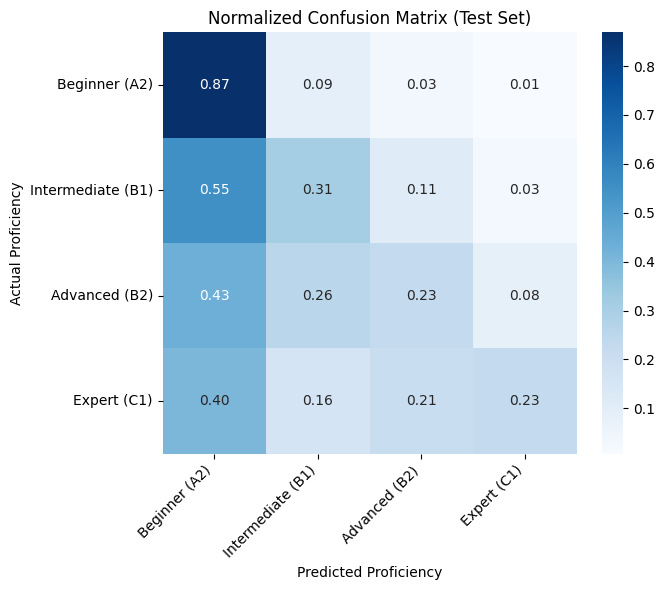


📖 TOP 10 DISCRIMINATIVE TERMS PER PROFICIENCY LEVEL
   (Higher log-prob → stronger association with class)

Beginner (A2):
   • read                      (log-prob: -3.570)
   • reading                   (log-prob: -3.747)
   • currently                 (log-prob: -3.747)
   • fiction                   (log-prob: -3.757)
   • favorites                 (log-prob: -4.446)
   • fantasy                   (log-prob: -4.474)
   • adult                     (log-prob: -4.605)
   • young                     (log-prob: -4.663)
   • romance                   (log-prob: -4.693)
   • mystery                   (log-prob: -4.694)

Intermediate (B1):
   • read                      (log-prob: -3.884)
   • reading                   (log-prob: -4.151)
   • currently                 (log-prob: -4.154)
   • fiction                   (log-prob: -4.173)
   • fantasy                   (log-prob: -4.340)
   • favorites                 (log-prob: -4.676)
   • adult                     (log-prob: -4.799)
   • y

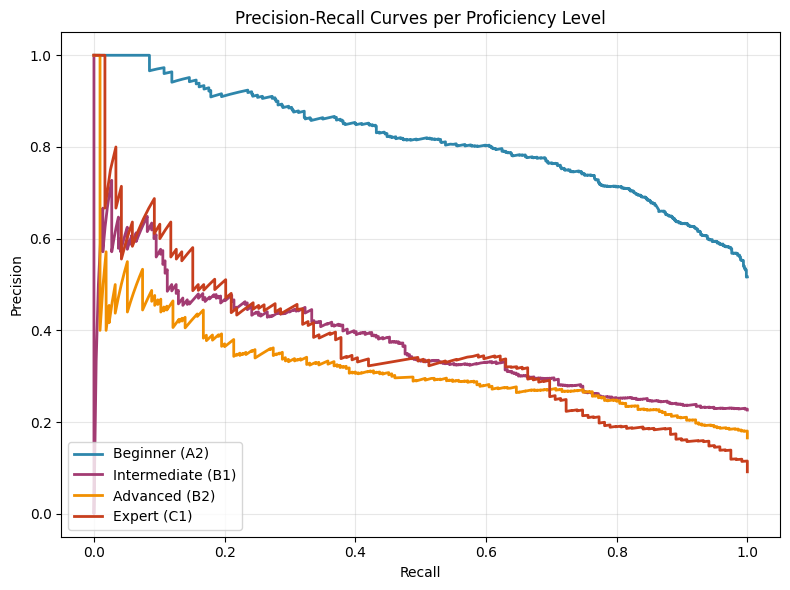

✅ Cell 4 complete. Ready for score generation & hybrid prep.


In [5]:
# 📊 Cell 4: Evaluation & Interpretability (CLO-1, CLO-3)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generate predictions on test set
y_pred_test = nb_model.predict(X_test)
y_proba_test = nb_model.predict_proba(X_test)

# 2. Overall metrics
print("📋 TEST SET PERFORMANCE SUMMARY")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"   Weighted F1: {f1_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"   Macro F1  : {f1_score(y_test, y_pred_test, average='macro'):.4f}\n")

# 3. Detailed classification report
level_names = ['Beginner (A2)', 'Intermediate (B1)', 'Advanced (B2)', 'Expert (C1)']
print("📋 CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=level_names))

# 4. Confusion Matrix (Normalized for interpretability)
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=level_names, yticklabels=level_names)
plt.title('Normalized Confusion Matrix (Test Set)')
plt.xlabel('Predicted Proficiency')
plt.ylabel('Actual Proficiency')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. 🔍 Interpretability: Top Discriminative Terms per Class
# Extract log-probabilities and map to feature names
feature_names = art['tfidf_vectorizer'].get_feature_names_out()
n_top = 10  # Show top 10 terms per level

print("\n📖 TOP 10 DISCRIMINATIVE TERMS PER PROFICIENCY LEVEL")
print("   (Higher log-prob → stronger association with class)\n")

for i, level in enumerate(level_names):
    # Get log-probabilities for class i
    log_probs = nb_model.feature_log_prob_[i]
    # Get indices of top terms
    top_idx = np.argsort(log_probs)[-n_top:][::-1]
    terms = [(feature_names[j], log_probs[j]) for j in top_idx]
    
    print(f"{level}:")
    for term, score in terms:
        print(f"   • {term:25} (log-prob: {score:.3f})")
    print()

# 6. 📈 Bonus: Class-wise Precision-Recall Tradeoff Visualization
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (level, color) in enumerate(zip(level_names, colors)):
    # Binary relevance for class i
    y_true_binary = (y_test == i).astype(int)
    y_score_binary = y_proba_test[:, i]
    
    precision, recall, _ = precision_recall_curve(y_true_binary, y_score_binary)
    plt.plot(recall, precision, color=color, label=level, linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves per Proficiency Level')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Cell 4 complete. Ready for score generation & hybrid prep.")

🎯 Generating content-based scores for all books...
✅ Probability matrix shape: (8660, 4)
✅ Score range per class: [0.000, 1.000]

💾 Saving artifacts...
✅ Artifacts saved:
   📄 nb_content_scores.parquet (8660 books)
   📄 nb_probabilities_normalized.npy ((8660, 4))
   📄 nb_score_scaler.pkl

📋 SAMPLE CONTENT SCORES (First 10 books):
   book_id    predicted_level  confidence  score_A2  score_B1  score_B2  score_C1
0        1      Beginner (A2)    0.779705  0.779705  0.075176  0.107261  0.040214
1        2  Intermediate (B1)    0.720072  0.241486  0.720072  0.041570  0.001089
2        3      Beginner (A2)    0.451178  0.451178  0.184419  0.273509  0.095991
3        4      Beginner (A2)    0.827592  0.827592  0.058811  0.018788  0.096710
4        5      Beginner (A2)    0.794273  0.794273  0.075501  0.080583  0.051835
5        6      Beginner (A2)    0.510895  0.510895  0.285383  0.151230  0.056405
6        7  Intermediate (B1)    0.592992  0.212495  0.592992  0.116504  0.083205
7        8  

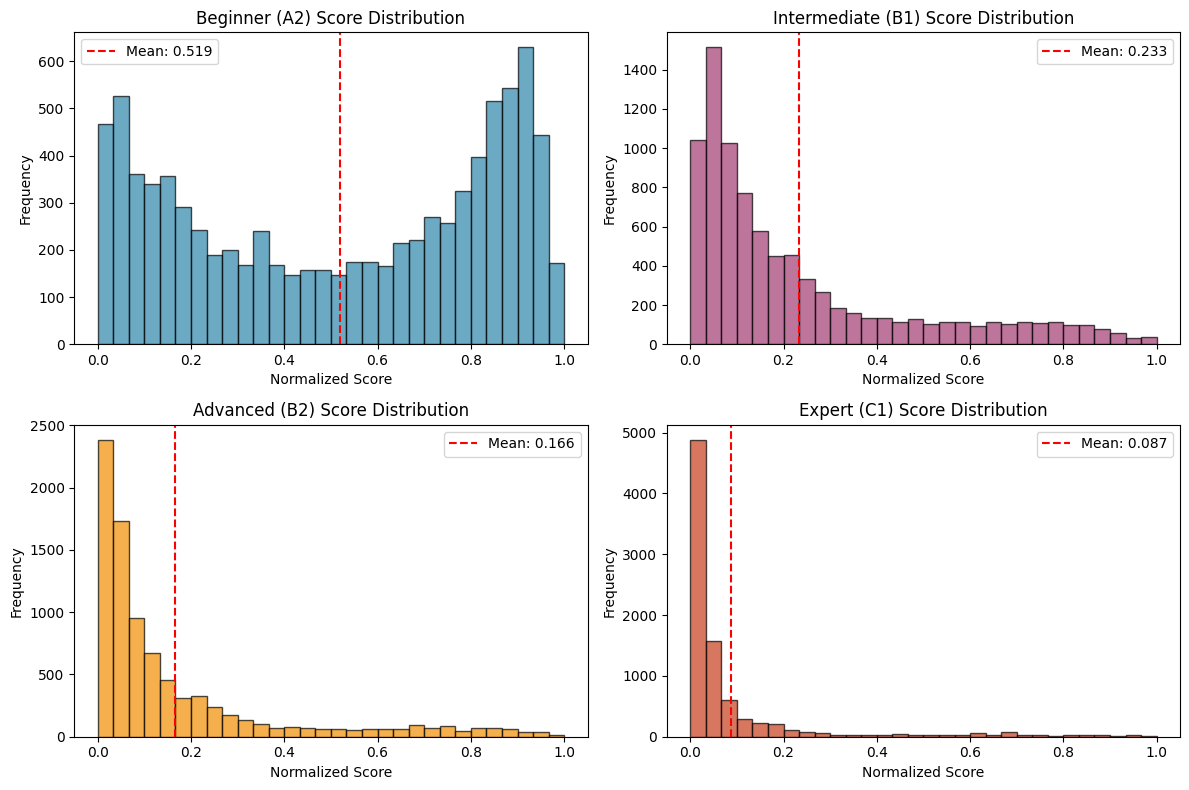


📊 SCORE STATISTICS PER PROFICIENCY LEVEL:
score_A2     → Mean: 0.519 | Std: 0.331 | Median: 0.566
score_B1     → Mean: 0.233 | Std: 0.242 | Median: 0.133
score_B2     → Mean: 0.166 | Std: 0.218 | Median: 0.073
score_C1     → Mean: 0.087 | Std: 0.168 | Median: 0.027

✅ Cell 5 complete. Ready for hybrid ensemble integration.


In [6]:
# 🔄 Cell 5: Generate Normalized Content Scores (Hybrid Prep)
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import os

ARTIFACTS_DIR = 'C:\\Users\\Qazi Maaz\\Desktop\\Bookbuddy\\BookBuddy\\bookbuddy_artifacts'

print("🎯 Generating content-based scores for all books...")

# 1. Predict probabilities for ALL books (enables cold-start & ensemble)
# Shape: (n_books, n_classes) where n_classes=4
proba_all = nb_model.predict_proba(X)  # X is the full TF-IDF matrix

# 2. Min-Max normalize each class probability to [0, 1] for weighted ensemble
# This ensures NB scores are on same scale as MLP predictions
scaler = MinMaxScaler(feature_range=(0, 1))
proba_norm = scaler.fit_transform(proba_all)

print(f"✅ Probability matrix shape: {proba_norm.shape}")
print(f"✅ Score range per class: [{proba_norm.min():.3f}, {proba_norm.max():.3f}]")

# 3. Build comprehensive scores DataFrame
level_names = ['Beginner (A2)', 'Intermediate (B1)', 'Advanced (B2)', 'Expert (C1)']
level_codes = ['A2', 'B1', 'B2', 'C1']

nb_scores_df = pd.DataFrame({
    'book_id': books_model[art['id_col']].values,
    'predicted_level_idx': nb_model.predict(X),
    'predicted_level': [level_names[i] for i in nb_model.predict(X)]
})

# Add normalized score for each proficiency level
for i, code in enumerate(level_codes):
    nb_scores_df[f'score_{code}'] = proba_norm[:, i]

# 4. Add confidence metric (max probability across classes)
nb_scores_df['confidence'] = proba_norm.max(axis=1)

# 5. Save artifacts for hybrid notebook
print("\n💾 Saving artifacts...")

# Save DataFrame for easy inspection
nb_scores_df.to_parquet(os.path.join(ARTIFACTS_DIR, 'nb_content_scores.parquet'), index=False)

# Save numpy array for fast loading in hybrid notebook
np.save(os.path.join(ARTIFACTS_DIR, 'nb_probabilities_normalized.npy'), proba_norm)

# Save scaler for transforming new books
import joblib
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, 'nb_score_scaler.pkl'))

print("✅ Artifacts saved:")
print(f"   📄 nb_content_scores.parquet ({len(nb_scores_df)} books)")
print(f"   📄 nb_probabilities_normalized.npy ({proba_norm.shape})")
print(f"   📄 nb_score_scaler.pkl")

# 6. Display sample scores
print("\n📋 SAMPLE CONTENT SCORES (First 10 books):")
display_cols = ['book_id', 'predicted_level', 'confidence'] + [f'score_{c}' for c in level_codes]
print(nb_scores_df[display_cols].head(10).to_string())

# 7. Score distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (code, color) in enumerate(zip(level_codes, ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])):
    axes[i].hist(nb_scores_df[f'score_{code}'], bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{level_names[i]} Score Distribution')
    axes[i].set_xlabel('Normalized Score')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(nb_scores_df[f'score_{code}'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {nb_scores_df[f"score_{code}"].mean():.3f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 8. Summary statistics
print("\n📊 SCORE STATISTICS PER PROFICIENCY LEVEL:")
for code in level_codes:
    col = f'score_{code}'
    print(f"{col:12} → Mean: {nb_scores_df[col].mean():.3f} | "
          f"Std: {nb_scores_df[col].std():.3f} | "
          f"Median: {nb_scores_df[col].median():.3f}")

print("\n✅ Cell 5 complete. Ready for hybrid ensemble integration.")